 # **Problem Statmet**

Even when irrigation is required, farmers often struggle to determine the exact amount of water needed by crops. Over-irrigation wastes water and nutrients, while under-irrigation can reduce crop growth and yield.

The objective of this model is to estimate the quantity of water required (in liters) using soil conditions, weather parameters, crop characteristics, and vegetation health indicators.

# **Import Libraries**

In [3]:
import numpy as np
import pandas as pd

# **Load Dataset**

In [4]:
df =pd.read_csv('D:\Machine Learning\Smart-Irrigation-Project\Data\processed\smart_irrigation_cleaned.csv')
df.head()

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0


# **Check Dataset Shape**

In [5]:
df.shape

(10000, 48)

# **Check Column Names**

In [6]:
df.columns

Index(['growth_stage', 'temperature', 'humidity', 'rainfall',
       'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure',
       'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature',
       'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter',
       'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days',
       'water_usage', 'pest_risk', 'disease_risk', 'crop_health_index',
       'previous_yield', 'groundwater_level', 'reservoir_level',
       'fertilizer_usage', 'labor_hours', 'water_quantity_required_liters',
       'future_soil_moisture_3day', 'crop_water_stress_level',
       'irrigation_required', 'yield_prediction', 'crop_type_Maize',
       'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat',
       'region_North', 'region_South', 'region_West', 'soil_type_Loamy',
       'soil_type_Sandy', 'soil_type_Silty', 'irrigation_type_Flood',
       'irrigation_type_Sprinkler'],
      dtype='object')

# **Check Data Types & Null Values**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   growth_stage                    10000 non-null  int64  
 1   temperature                     10000 non-null  float64
 2   humidity                        10000 non-null  float64
 3   rainfall                        10000 non-null  float64
 4   forecast_rainfall               10000 non-null  float64
 5   wind_speed                      10000 non-null  float64
 6   solar_radiation                 10000 non-null  float64
 7   pressure                        10000 non-null  float64
 8   cloud_cover                     10000 non-null  float64
 9   dew_point                       10000 non-null  float64
 10  soil_moisture                   10000 non-null  float64
 11  soil_temperature                10000 non-null  float64
 12  soil_ph                         1

In [8]:
df['crop_water_stress_level'].unique()

array([0, 1, 2])

# **Feature Selection**

In [9]:
X = df.drop(columns=['water_quantity_required_liters','irrigation_required','future_soil_moisture_3day','yield_prediction','water_usage'],axis=1)
y = df['water_quantity_required_liters']

# T**rain_Test_Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.shape

(8000, 43)

In [12]:
X_test.shape

(2000, 43)

In [13]:
y_train.shape

(8000,)

In [14]:
y_test.shape

(2000,)

# **Model Building**

# **1.Multiple Linear Regression**

In [15]:
from sklearn.linear_model import LinearRegression

# **Train Model**

In [16]:
linear = LinearRegression()
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Training & Testing Prediction
train_prediction = linear.predict(X_train)
test_prediction = linear.predict(X_test)

In [18]:
# Check R2 score of training & testing
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train,train_prediction)
test_r2 = r2_score(y_test,test_prediction)


print("R2 Score Of Training Is:",round(train_r2,4))
print("R2 Score Of Testing Is:",round(test_r2,4))


r2_gap = train_r2 - test_r2

print("R2 Score Gap Is:",round(r2_gap,4))

R2 Score Of Training Is: 0.8643
R2 Score Of Testing Is: 0.8627
R2 Score Gap Is: 0.0016


# **Check MAE, MSE,RMSE Score**

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error

mae = mean_absolute_error(y_test,test_prediction)
mse = mean_squared_error(y_test,test_prediction)
rmse = np.sqrt(mse)

print("Mean Absolute Error Is:",round(mae,4))
print("Mean Squred Error Is:",round(mse,4))
print("Root Mean Squred Error Is:",round(rmse,4))

Mean Absolute Error Is: 7.2665
Mean Squred Error Is: 72.8382
Root Mean Squred Error Is: 8.5345


# **Actual vs Predicted Plot**

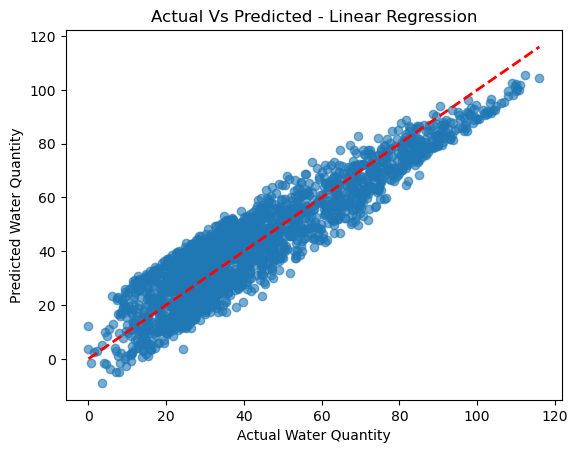

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(y_test,test_prediction,alpha=0.6)
plt.plot( 
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual Water Quantity")
plt.ylabel("Predicted Water Quantity")
plt.title("Actual Vs Predicted - Linear Regression")
plt.show()

# **Residual Plot**

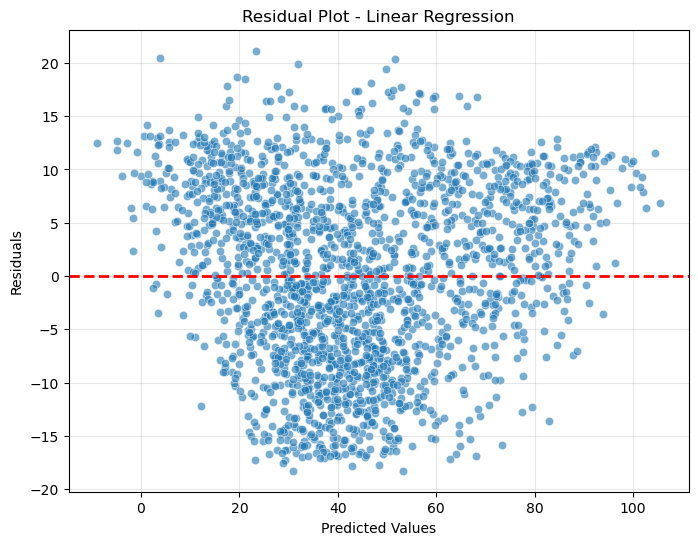

In [21]:
residuals = y_test - test_prediction

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=test_prediction,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')

plt.grid(alpha=0.3)
plt.show()

# **Residual Distribution**

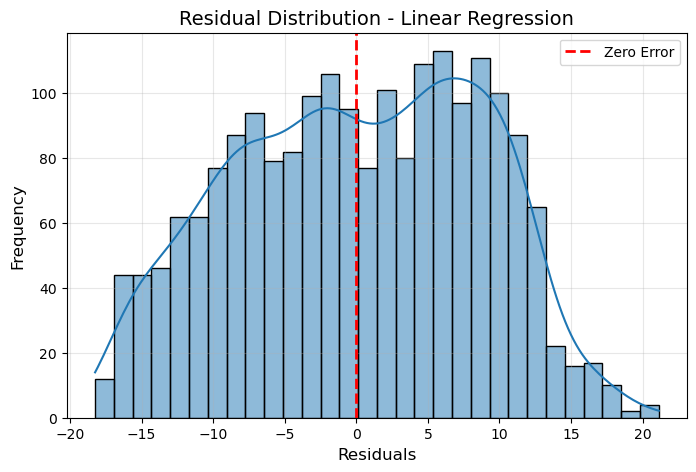

In [22]:
residuals = y_test - test_prediction

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.title('Residual Distribution - Linear Regression', fontsize=14)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **Coefficient Table**

In [23]:
coef_df = pd.DataFrame({
    'Features' : X.columns,
    'Coefficient' : linear.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nTop Positive Features")
print(coef_df.head(10))

print("\nTop Negative Features")
print(coef_df.tail(10))


Top Positive Features
                     Features  Coefficient
19         evapotranspiration     2.012754
1                 temperature     0.781380
36               region_South     0.388065
34            crop_type_Wheat     0.317149
38            soil_type_Loamy     0.251231
42  irrigation_type_Sprinkler     0.096911
17                         ec     0.067099
12                    soil_ph     0.056097
0                growth_stage     0.035988
16             organic_matter     0.034023

Top Negative Features
                   Features  Coefficient
35             region_North    -0.115588
33      crop_type_Sugarcane    -0.152018
39          soil_type_Sandy    -0.166295
32           crop_type_Rice    -0.271574
31          crop_type_Maize    -0.314172
37              region_West    -0.347937
40          soil_type_Silty    -0.355826
20                     ndvi    -0.441924
10            soil_moisture    -0.769793
30  crop_water_stress_level    -6.923013


# **Feature Importance Chart**

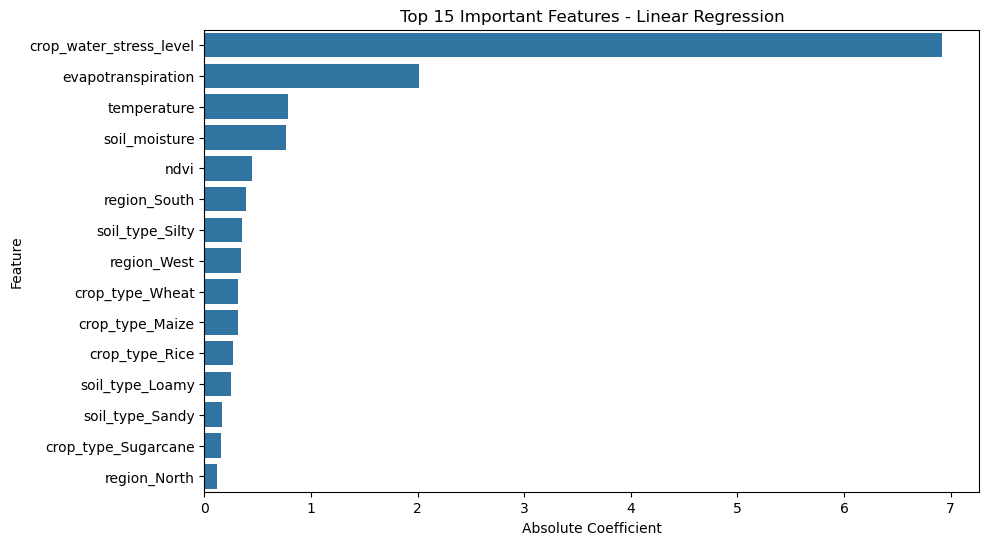

In [24]:
import seaborn as sns

coef_df['Abs_Coefficient'] = abs(
    coef_df['Coefficient']
)

top_features = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

# column name is 'Features' in coef_df (not 'Feature')
sns.barplot(
    data=top_features,
    x='Abs_Coefficient',
    y='Features'
)

plt.title('Top 15 Important Features - Linear Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')

plt.show()

# **2.Decision Tree Regressor**

In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
decision_reg = DecisionTreeRegressor()
decision_reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
#checking testing and training prediction
train_pred_dt = decision_reg.predict(X_train)
test_pred_dt = decision_reg.predict(X_test)

In [28]:
train_r2_dt = r2_score(y_train, train_pred_dt)

train_mae_dt = mean_absolute_error(y_train, train_pred_dt)

train_mse_dt = mean_squared_error(y_train, train_pred_dt)

train_rmse_dt = train_mse_dt ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_dt,4))
print("MAE      :", round(train_mae_dt,4))
print("MSE      :", round(train_mse_dt,4))
print("RMSE     :", round(train_rmse_dt,4))



test_r2_dt = r2_score(y_test, test_pred_dt)

test_mae_dt = mean_absolute_error(y_test, test_pred_dt)

test_mse_dt = mean_squared_error(y_test, test_pred_dt)

test_rmse_dt = test_mse_dt ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_dt,4))
print("MAE      :", round(test_mae_dt,4))
print("MSE      :", round(test_mse_dt,4))
print("RMSE     :", round(test_rmse_dt,4))

===== Training Metrics =====
R² Score : 1.0
MAE      : 0.0
MSE      : 0.0
RMSE     : 0.0

===== Testing Metrics =====
R² Score : 0.9721
MAE      : 2.7665
MSE      : 14.8159
RMSE     : 3.8491


In [29]:
# Check R2 score of training & testing
r2_gap = train_r2_dt - test_r2_dt

print("R2 Score Gap Is:",round(r2_gap,4))

R2 Score Gap Is: 0.0279


# **Actual VS Predicted Plot**

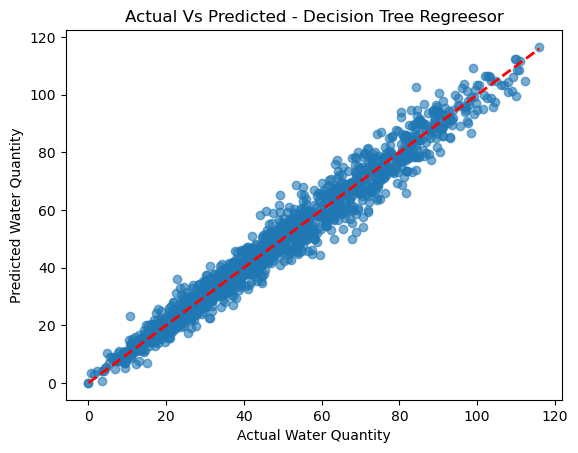

In [30]:
plt.scatter(y_test,test_pred_dt,alpha=0.6)
plt.plot( 
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual Water Quantity")
plt.ylabel("Predicted Water Quantity")
plt.title("Actual Vs Predicted - Decision Tree Regreesor")
plt.show()

# **Residual Plot**

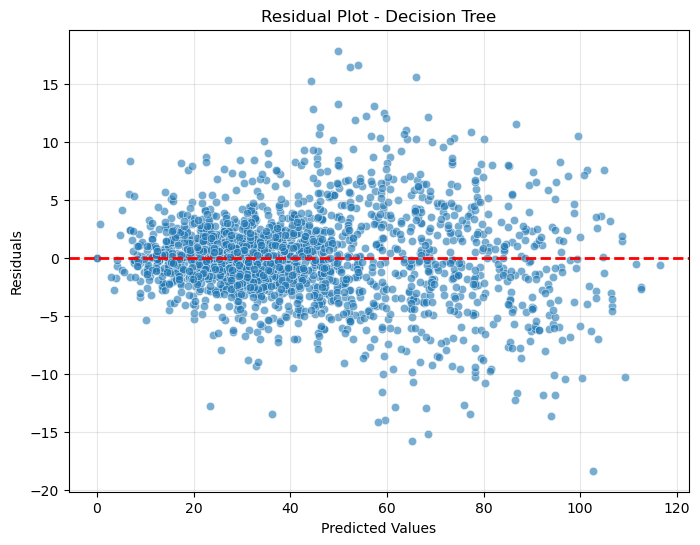

In [31]:
residuals_dt = y_test - test_pred_dt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=test_pred_dt,
    y=residuals_dt,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Decision Tree')

plt.grid(alpha=0.3)
plt.show()

# **Residual Distribution**

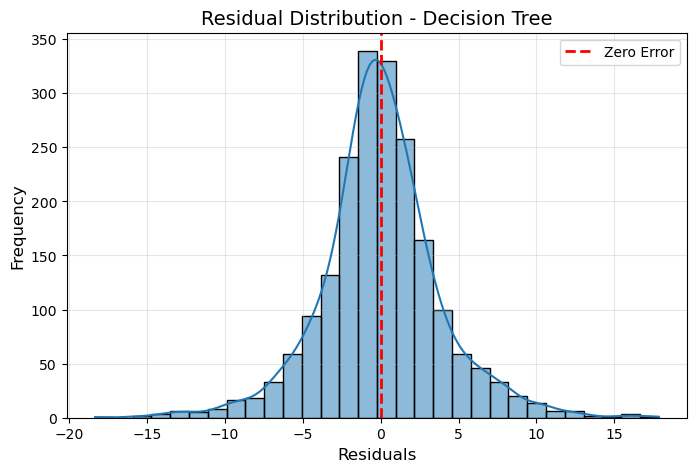

In [32]:
residuals_dt = y_test - test_pred_dt

plt.figure(figsize=(8,5))

sns.histplot(
    residuals_dt,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.title('Residual Distribution - Decision Tree', fontsize=14)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **Feature Importance**

In [33]:
feature_importance = pd.DataFrame({
    'Features' : X.columns,
    'Importance' : decision_reg.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Positive Features")
print(feature_importance.head(10))

top_features_dt = feature_importance.head(10)


Top Positive Features
                   Features  Importance
10            soil_moisture    0.776905
19       evapotranspiration    0.090105
1               temperature    0.078815
3                  rainfall    0.033704
30  crop_water_stress_level    0.012488
22                pest_risk    0.000847
7                  pressure    0.000374
13                 nitrogen    0.000363
8               cloud_cover    0.000361
24        crop_health_index    0.000352


#

C:\Users\Sourabh\AppData\Local\Temp\ipykernel_16328\1263119603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


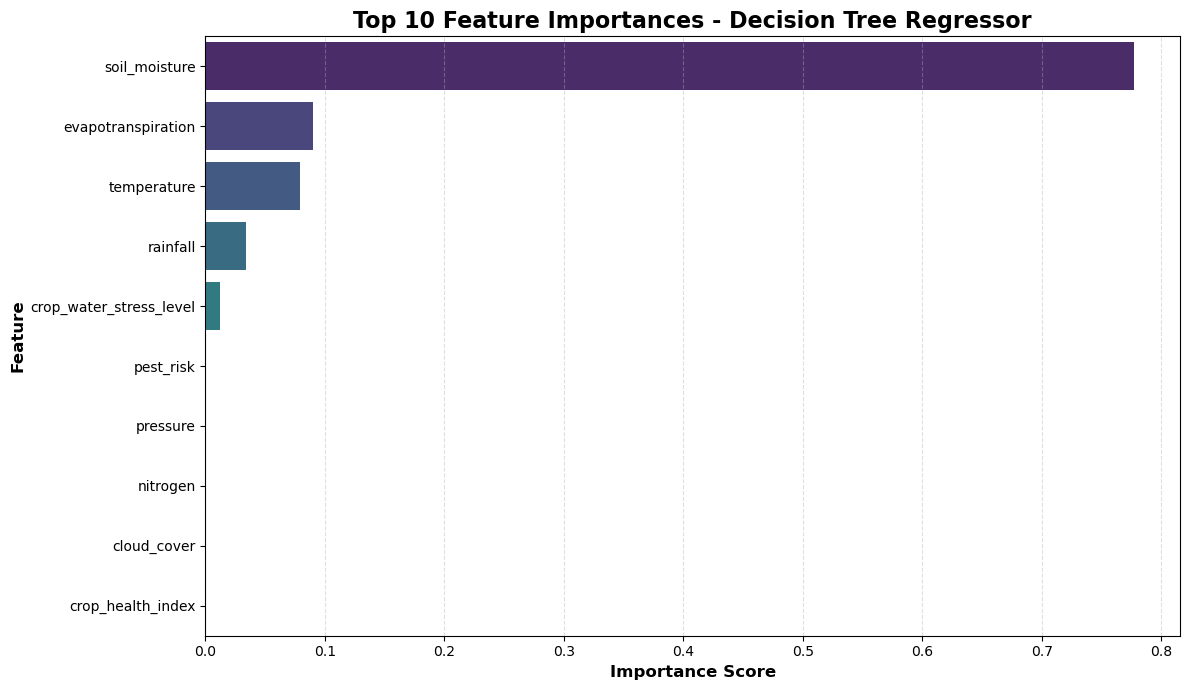

In [34]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_features_dt,
    x='Importance',
    y='Features',
    palette='viridis'
)

plt.title(
    'Top 10 Feature Importances - Decision Tree Regressor',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# **Hyper-Parameter Tuning for Decision Tree Regreesor**

In [35]:
pram_grid={
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', None]
}


In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=pram_grid,
    cv=5,
    verbose=1,
    n_jobs=-1,
    scoring='r2'
)

In [38]:
grid_dt.fit(X_train,y_train)

print("Best Parameters:",grid_dt.best_params_)

print("\nBest r2 Score:")
print(round(grid_dt.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best r2 Score:
0.9709


In [39]:
best_dt = grid_dt.best_estimator_

In [40]:
train_prediction_dt = best_dt.predict(X_train)
test_predection_dt = best_dt.predict(X_test)

In [41]:
train_r2_dt_tune = r2_score(y_train, train_prediction_dt)

train_mae_dt_tune = mean_absolute_error(y_train, train_prediction_dt)

train_mse_dt_tune = mean_squared_error(y_train, train_prediction_dt)

train_rmse_dt_tune = train_mse_dt_tune ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_dt_tune,4))
print("MAE      :", round(train_mae_dt_tune,4))
print("MSE      :", round(train_mse_dt_tune,4))
print("RMSE     :", round(train_rmse_dt_tune,4))



test_r2_dt_tune = r2_score(y_test, test_predection_dt)

test_mae_dt_tune = mean_absolute_error(y_test, test_predection_dt)

test_mse_dt_tune = mean_squared_error(y_test, test_predection_dt)

test_rmse_dt_tune = test_mse_dt_tune ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_dt_tune,4))
print("MAE      :", round(test_mae_dt_tune,4))
print("MSE      :", round(test_mse_dt_tune,4))
print("RMSE     :", round(test_rmse_dt_tune,4))

===== Training Metrics =====
R² Score : 0.9957
MAE      : 1.0625
MSE      : 2.2535
RMSE     : 1.5012

===== Testing Metrics =====
R² Score : 0.9749
MAE      : 2.648
MSE      : 13.3179
RMSE     : 3.6494


In [42]:

r2_gap_tune = train_r2_dt_tune - test_r2_dt_tune

print("R2 Score Gap Is:",round(r2_gap_tune,4))


R2 Score Gap Is: 0.0208


# **Feature Importance**

In [43]:
feature_importance_tune = pd.DataFrame({
    'Features' : X.columns,
    'Importance' : best_dt.feature_importances_
})

feature_importance_tune = feature_importance_tune.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Positive Features")
print(feature_importance_tune.head(10))

top_features_dt_tune = feature_importance_tune.head(10)


Top Positive Features
                   Features  Importance
10            soil_moisture    0.779886
19       evapotranspiration    0.090425
1               temperature    0.079023
3                  rainfall    0.033693
30  crop_water_stress_level    0.012511
22                pest_risk    0.000733
7                  pressure    0.000245
17                       ec    0.000219
12                  soil_ph    0.000211
8               cloud_cover    0.000192


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_16328\3128753207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


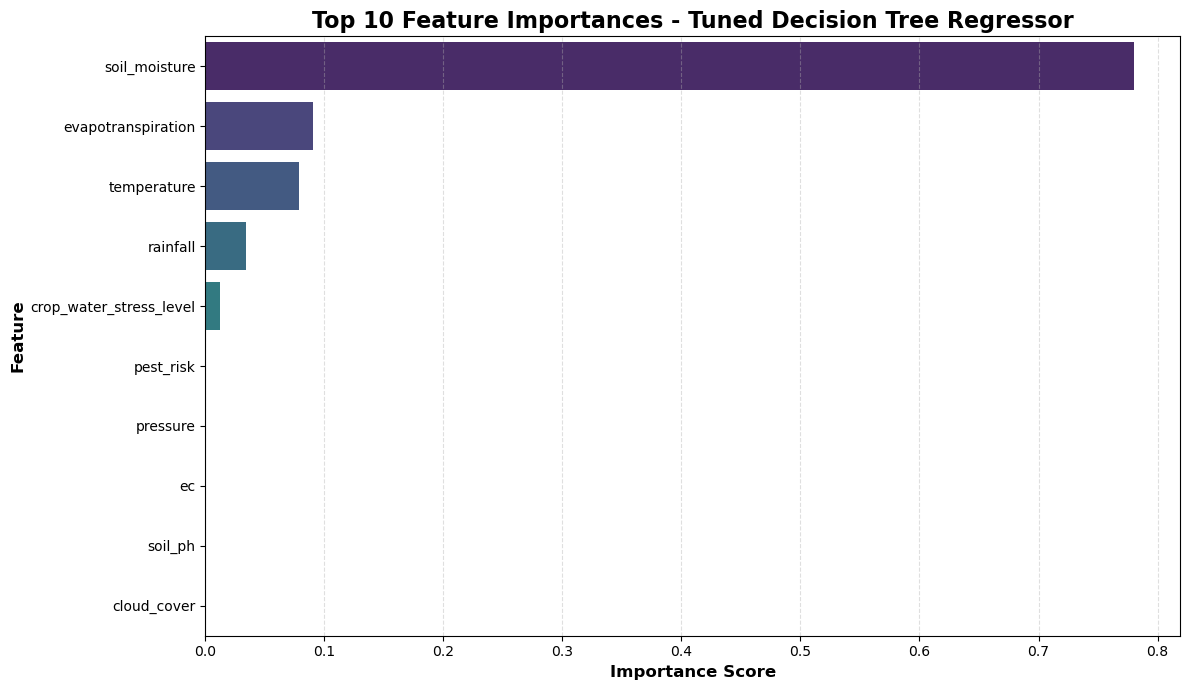

In [44]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_features_dt_tune,
    x='Importance',
    y='Features',
    palette='viridis'
)

plt.title(
    'Top 10 Feature Importances - Tuned Decision Tree Regressor',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# **Comparison On Default & Tuned Decision Tree**

In [45]:
Decision_Comaparison = pd.DataFrame ({
    
    'Metric' : [
        'Train R²',
        'Test R²',
        'MAE',
        'RMSE'
    ],
    'Default DT' : [
        train_r2_dt,
        test_r2_dt,
        test_mae_dt,
        test_rmse_dt
    ],
    'Tuned DT' : [
        train_r2_dt_tune,
        test_r2_dt_tune,
        test_mae_dt_tune,
        test_rmse_dt_tune
    ]
    
    
})
Decision_Comaparison.iloc[:,1:] = Decision_Comaparison.iloc[:,1:].round(3)

In [46]:
Decision_Comaparison

,Metric,Default DT,Tuned DT
0,Train R²,1.000,0.996
1,Test R²,0.972,0.975
2,MAE,2.766,2.648
3,RMSE,3.849,3.649


The hyperparameter-tuned Decision Tree Regressor outperformed the default Decision Tree model. The tuned model achieved a Test R² score of 0.975 compared to 0.971 for the default model. Additionally, MAE decreased from 2.810 to 2.648 and RMSE decreased from 3.914 to 3.649. The reduction in training performance from 1.000 to 0.996 indicates that overfitting was reduced while maintaining excellent predictive accuracy. Therefore, the tuned Decision Tree Regressor was selected as the preferred Decision Tree model.


# **3.Random Forest Regressor**

In [47]:
from sklearn.ensemble import RandomForestRegressor


random_reg = RandomForestRegressor()
random_reg.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
#Check Train and Test prediction
train_pred_rf = random_reg.predict(X_train)
test_pred_rf = random_reg.predict(X_test)

In [49]:
train_r2_rf = r2_score(y_train, train_pred_rf)

train_mae_rf = mean_absolute_error(y_train,train_pred_rf )

train_mse_rf = mean_squared_error(y_train, train_pred_rf)

train_rmse_rf = train_mse_rf ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_rf,4))
print("MAE      :", round(train_mae_rf,4))
print("MSE      :", round(train_mse_rf,4))
print("RMSE     :", round(train_rmse_rf,4))



test_r2_rf = r2_score(y_test, test_pred_rf)

test_mae_rf = mean_absolute_error(y_test, test_pred_rf)

test_mse_rf = mean_squared_error(y_test, test_pred_rf)

test_rmse_rf = test_mse_rf ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_rf,4))
print("MAE      :", round(test_mae_rf,4))
print("MSE      :", round(test_mse_rf,4))
print("RMSE     :", round(test_rmse_rf,4))

===== Training Metrics =====
R² Score : 0.999
MAE      : 0.5193
MSE      : 0.5295
RMSE     : 0.7277

===== Testing Metrics =====
R² Score : 0.9937
MAE      : 1.3121
MSE      : 3.3636
RMSE     : 1.834


In [50]:
# Check R2 score gap

R2_score_gap_rf = train_r2_rf - test_r2_rf

print("R2 Score Gap Is:",round(R2_score_gap_rf,4))

R2 Score Gap Is: 0.0053


# **Actual VS Predicted Plot**

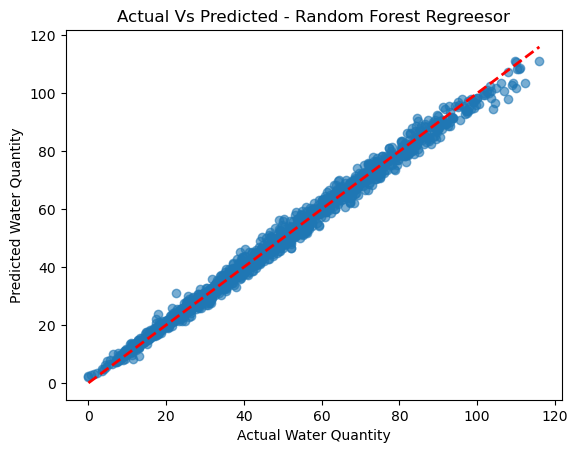

In [51]:
plt.scatter(y_test,test_pred_rf,alpha=0.6)
plt.plot( 
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual Water Quantity")
plt.ylabel("Predicted Water Quantity")
plt.title("Actual Vs Predicted - Random Forest Regreesor")
plt.show()

# **Residual Plot**

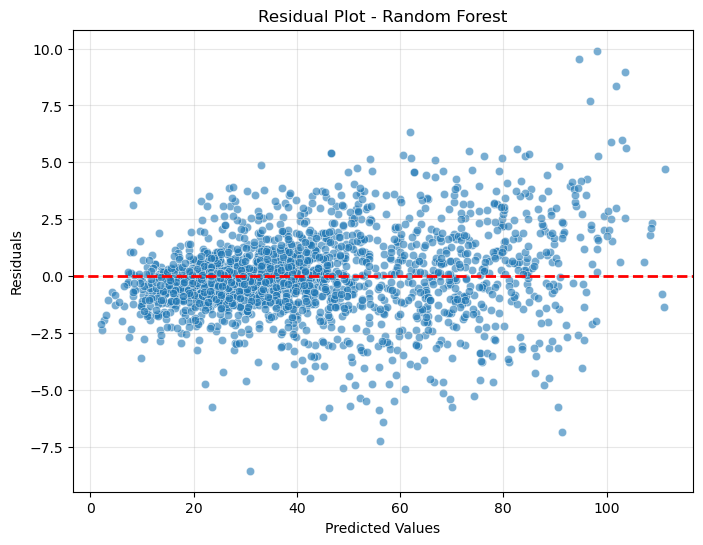

In [52]:
residuals_rf = y_test - test_pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=test_pred_rf,
    y=residuals_rf,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')

plt.grid(alpha=0.3)
plt.show()

# **Feature Imortance Table**

In [53]:
feature_importance = pd.DataFrame({
    'Features' : X.columns,
    'Importance' : random_reg.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Positive Features")
print(feature_importance.head(10))

top_features_rf = feature_importance.head(10)


Top Positive Features
                   Features  Importance
10            soil_moisture    0.764511
19       evapotranspiration    0.090177
1               temperature    0.080105
3                  rainfall    0.032898
30  crop_water_stress_level    0.023356
22                pest_risk    0.000485
8               cloud_cover    0.000354
27          reservoir_level    0.000352
26        groundwater_level    0.000346
17                       ec    0.000346


C:\Users\Sourabh\AppData\Local\Temp\ipykernel_16328\550396542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


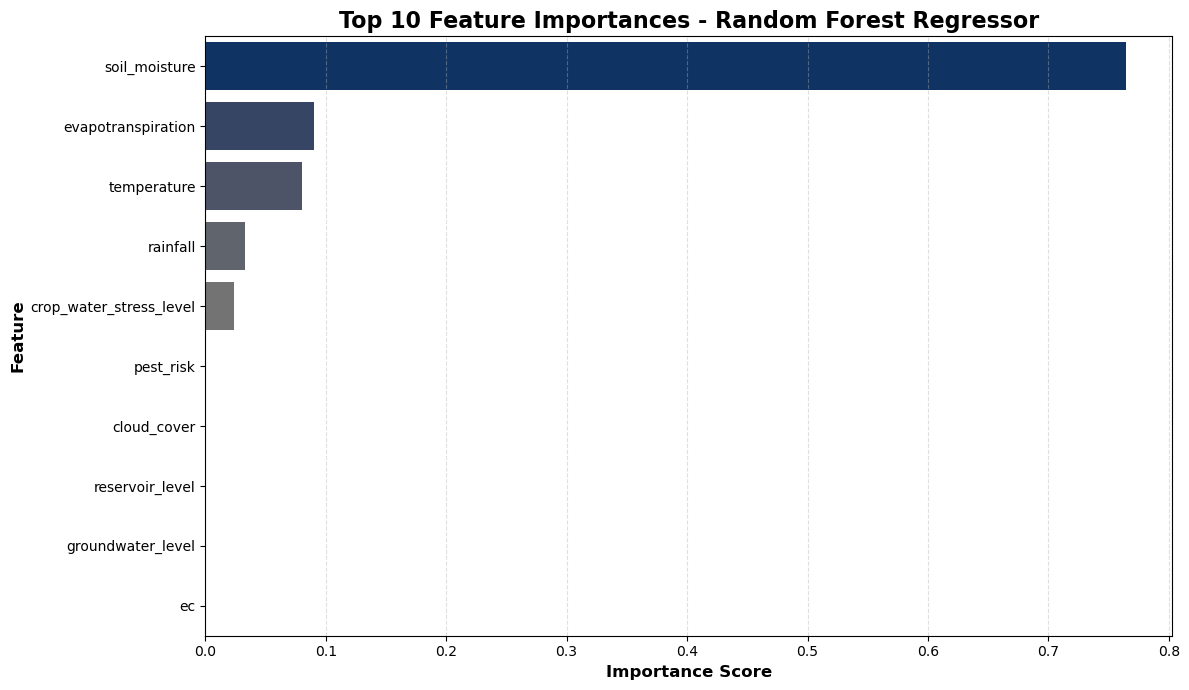

In [54]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_features_rf,
    x='Importance',
    y='Features',
    palette='cividis'
)

plt.title(
    'Top 10 Feature Importances - Random Forest Regressor',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

 # **Hyperparameter Tuned Random Forest**

In [55]:
param_grid_rf = {
    'n_estimators': [300, 500],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', None]
}


In [56]:
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [57]:
grid_search_rf.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [20, 30, ...], 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [58]:
best_rf_tune = grid_search_rf.best_estimator_

# grid_search_rf holds the search results; use it to access best_params_ and best_score_
print("Best Parameters:", grid_search_rf.best_params_)

print("\nBest r2 Score:")
print(round(grid_search_rf.best_score_, 4))

Best Parameters: {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Best r2 Score:
0.9923


In [59]:
train_pred_rf_tune = best_rf_tune.predict(X_train)
test_pred_rf_tune  = best_rf_tune.predict(X_test)

In [60]:
train_r2_rf_tune = r2_score(y_train, train_pred_rf_tune)

train_mae_rf_tune = mean_absolute_error(y_train,train_pred_rf_tune )

train_mse_rf_tune = mean_squared_error(y_train, train_pred_rf_tune)

train_rmse_rf_tune = train_mse_rf_tune ** 0.5

print("===== Training Metrics =====")
print("R² Score :", round(train_r2_rf_tune,4))
print("MAE      :", round(train_mae_rf_tune,4))
print("MSE      :", round(train_mse_rf_tune,4))
print("RMSE     :", round(train_rmse_rf_tune,4))



test_r2_rf_tune = r2_score(y_test, test_pred_rf_tune)

test_mae_rf_tune = mean_absolute_error(y_test, test_pred_rf_tune)

test_mse_rf_tune = mean_squared_error(y_test, test_pred_rf_tune)

test_rmse_rf_tune = test_mse_rf_tune ** 0.5

print("\n===== Testing Metrics =====")
print("R² Score :", round(test_r2_rf_tune,4))
print("MAE      :", round(test_mae_rf_tune,4))
print("MSE      :", round(test_mse_rf_tune,4))
print("RMSE     :", round(test_rmse_rf_tune,4))

===== Training Metrics =====
R² Score : 0.9991
MAE      : 0.4924
MSE      : 0.4757
RMSE     : 0.6897

===== Testing Metrics =====
R² Score : 0.9939
MAE      : 1.2772
MSE      : 3.2247
RMSE     : 1.7957


In [61]:
r2_gap_rf_tune = train_r2_rf_tune - test_r2_rf_tune

print("\nR² Score Gap Is:",
      round(r2_gap_rf_tune,4))


R² Score Gap Is: 0.0052


# **Feature Importance**

In [62]:
feature_importance_rf_tune = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_tune.feature_importances_
})

feature_importance_rf_tune = feature_importance_rf_tune.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_rf_tune.head(10))

                    Feature  Importance
10            soil_moisture    0.762297
19       evapotranspiration    0.090339
1               temperature    0.078951
3                  rainfall    0.032832
30  crop_water_stress_level    0.026600
22                pest_risk    0.000530
27          reservoir_level    0.000348
26        groundwater_level    0.000347
7                  pressure    0.000344
4         forecast_rainfall    0.000339


In [63]:
feature_importance_rf_tune.to_csv(
    "../models/water_feature_importance.csv",
    index=False
)

# **Comparison Of All Models**

In [64]:
comparison_df = pd.DataFrame({

    'Metric': [
        'Train R²',
        'Test R²',
        'MAE',
        'RMSE'
    ],

    'Linear Regression': [
        train_r2,
        test_r2,
        mae,
        rmse
    ],

    'Tuned Decision Tree': [
        train_r2_dt_tune,
        test_r2_dt_tune,
        test_mae_dt_tune,
        test_rmse_dt_tune
    ],
    'Tuned Random Forest': [
        train_r2_rf_tune,
        test_r2_rf_tune,
        test_mae_rf_tune,
        test_rmse_rf_tune
    ]

})
comparison_df = comparison_df.round(4)
comparison_df

,Metric,Linear Regression,Tuned Decision Tree,Tuned Random Forest
0,Train R²,0.8643,0.9957,0.9991
1,Test R²,0.8627,0.9749,0.9939
2,MAE,7.2665,2.6480,1.2772
3,RMSE,8.5345,3.6494,1.7957


Three regression models were evaluated for predicting irrigation water quantity requirements: Linear Regression, Tuned Decision Tree Regressor, and Tuned Random Forest Regressor. Model performance was assessed using R² Score, MAE, and RMSE.

The Tuned Random Forest Regressor achieved the best overall performance with a Train R² of 0.9991, Test R² of 0.9939, MAE of 1.2772 liters, and RMSE of 1.7957 liters. The model demonstrated excellent predictive accuracy and a very small train-test performance gap, indicating minimal overfitting and strong generalization capability.

Therefore, the Tuned Random Forest Regressor was selected as the final model for predicting water quantity requirements in the smart irrigation system.


# **Save Model**

In [65]:
import joblib

joblib.dump(
    best_rf_tune,
    "../models/water_quantity_required_model.pkl"
)

['../models/water_quantity_required_model.pkl']

In [66]:
import os

print(os.listdir("../models"))

['crop_water_stress_level.pkl', 'growth_stage_encoder.pkl', 'irrigation_features.pkl', 'irrigation_required_model.pkl', 'water_defaults_values.pkl', 'water_feature_importance.csv', 'water_quantity_features.pkl', 'water_quantity_required_model.pkl', 'yield_default_values.pkl', 'yield_prediction_features.pkl', 'yield_prediction_model.pkl', 'yield_prediction_model_lr_backup.pkl']


# **Save Feature names**

In [67]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "../models/water_quantity_features.pkl"
)

['../models/water_quantity_features.pkl']

In [68]:
feature_names = joblib.load(
    "../models/water_quantity_features.pkl"
)

print(feature_names)

['growth_stage', 'temperature', 'humidity', 'rainfall', 'forecast_rainfall', 'wind_speed', 'solar_radiation', 'pressure', 'cloud_cover', 'dew_point', 'soil_moisture', 'soil_temperature', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'organic_matter', 'ec', 'leaf_wetness', 'evapotranspiration', 'ndvi', 'crop_age_days', 'pest_risk', 'disease_risk', 'crop_health_index', 'previous_yield', 'groundwater_level', 'reservoir_level', 'fertilizer_usage', 'labor_hours', 'crop_water_stress_level', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Sugarcane', 'crop_type_Wheat', 'region_North', 'region_South', 'region_West', 'soil_type_Loamy', 'soil_type_Sandy', 'soil_type_Silty', 'irrigation_type_Flood', 'irrigation_type_Sprinkler']


In [69]:
corr = df.corr(numeric_only=True)

print(
    corr["future_soil_moisture_3day"]
    .sort_values(ascending=False)
    .head(20)
)

future_soil_moisture_3day    1.000000
soil_moisture                0.992568
crop_water_stress_level      0.206177
forecast_rainfall            0.110280
solar_radiation              0.028629
crop_type_Sugarcane          0.017221
leaf_wetness                 0.014197
disease_risk                 0.012647
rainfall                     0.012236
organic_matter               0.010596
region_South                 0.009973
soil_ph                      0.009560
crop_health_index            0.008989
growth_stage                 0.008791
evapotranspiration           0.007517
soil_temperature             0.007084
region_West                  0.005662
yield_prediction             0.005581
ndvi                         0.005363
irrigation_type_Flood        0.004673
Name: future_soil_moisture_3day, dtype: float64


In [70]:
row = df.iloc[100]

actual = row["water_quantity_required_liters"]

In [71]:
# Use the trained model and the feature names (feature_names or X.columns)
features = feature_names if 'feature_names' in globals() else (X.columns.tolist() if 'X' in globals() else None)
if features is None:
    raise NameError("Feature names not found. Ensure 'feature_names' or 'X' is defined in the notebook.")

input_df = pd.DataFrame([row[features]])

# Call predict on the trained estimator, not on an ndarray of predictions
pred = best_rf_tune.predict(input_df)[0]

print(actual)
print(pred)

69.65
69.15430000000042


In [72]:
default_water_values = {
    "growth_stage": df["growth_stage"].mean(),
    "temperature": df["temperature"].mean(),
    "humidity": df["humidity"].mean(),
    "rainfall": df["rainfall"].mean(),
    "forecast_rainfall": df["forecast_rainfall"].mean(),
    "wind_speed": df["wind_speed"].mean(),
    "solar_radiation": df["solar_radiation"].mean(),
    "pressure": df["pressure"].mean(),
    "cloud_cover": df["cloud_cover"].mean(),
    "dew_point": df["dew_point"].mean(),

    "soil_moisture": df["soil_moisture"].mean(),
    "soil_temperature": df["soil_temperature"].mean(),
    "soil_ph": df["soil_ph"].mean(),

    "nitrogen": df["nitrogen"].mean(),
    "phosphorus": df["phosphorus"].mean(),
    "potassium": df["potassium"].mean(),
    "organic_matter": df["organic_matter"].mean(),
    "ec": df["ec"].mean(),

    "leaf_wetness": df["leaf_wetness"].mean(),
    "evapotranspiration": df["evapotranspiration"].mean(),

    "ndvi": df["ndvi"].mean(),
    "crop_age_days": df["crop_age_days"].mean(),

    "water_usage": df["water_usage"].mean(),
    "pest_risk": df["pest_risk"].mean(),
    "disease_risk": df["disease_risk"].mean(),
    "crop_health_index": df["crop_health_index"].mean(),

    "previous_yield": df["previous_yield"].mean(),
    "groundwater_level": df["groundwater_level"].mean(),
    "reservoir_level": df["reservoir_level"].mean(),
    "fertilizer_usage": df["fertilizer_usage"].mean(),
    "labor_hours": df["labor_hours"].mean()
}

print(default_water_values)

{'growth_stage': np.float64(1.4857), 'temperature': np.float64(29.978526000000002), 'humidity': np.float64(57.259388), 'rainfall': np.float64(151.030532), 'forecast_rainfall': np.float64(50.064710000000005), 'wind_speed': np.float64(14.978688), 'solar_radiation': np.float64(551.289992), 'pressure': np.float64(999.6037210000001), 'cloud_cover': np.float64(49.889210999999996), 'dew_point': np.float64(15.087630000000003), 'soil_moisture': np.float64(42.001316), 'soil_temperature': np.float64(25.139476), 'soil_ph': np.float64(6.532541999999999), 'nitrogen': np.float64(74.2918), 'phosphorus': np.float64(62.1759), 'potassium': np.float64(77.6604), 'organic_matter': np.float64(4.260173), 'ec': np.float64(1.555951), 'leaf_wetness': np.float64(49.68676), 'evapotranspiration': np.float64(5.969628), 'ndvi': np.float64(0.5286959000000001), 'crop_age_days': np.float64(89.3602), 'water_usage': np.float64(523.029872), 'pest_risk': np.float64(49.7808), 'disease_risk': np.float64(49.9163), 'crop_health

In [73]:
import joblib

joblib.dump(
    default_water_values,
    "../models/water_defaults_values.pkl"
)

['../models/water_defaults_values.pkl']

In [74]:
water_defaults = joblib.load(
    "../models/water_defaults_values.pkl"
)

In [75]:
print(water_defaults)

{'growth_stage': np.float64(1.4857), 'temperature': np.float64(29.978526000000002), 'humidity': np.float64(57.259388), 'rainfall': np.float64(151.030532), 'forecast_rainfall': np.float64(50.064710000000005), 'wind_speed': np.float64(14.978688), 'solar_radiation': np.float64(551.289992), 'pressure': np.float64(999.6037210000001), 'cloud_cover': np.float64(49.889210999999996), 'dew_point': np.float64(15.087630000000003), 'soil_moisture': np.float64(42.001316), 'soil_temperature': np.float64(25.139476), 'soil_ph': np.float64(6.532541999999999), 'nitrogen': np.float64(74.2918), 'phosphorus': np.float64(62.1759), 'potassium': np.float64(77.6604), 'organic_matter': np.float64(4.260173), 'ec': np.float64(1.555951), 'leaf_wetness': np.float64(49.68676), 'evapotranspiration': np.float64(5.969628), 'ndvi': np.float64(0.5286959000000001), 'crop_age_days': np.float64(89.3602), 'water_usage': np.float64(523.029872), 'pest_risk': np.float64(49.7808), 'disease_risk': np.float64(49.9163), 'crop_health

In [76]:
# joblib is already imported earlier in the notebook; do not re-import it here.

# choose an available feature list: prefer 'feature_names', then 'features'
water_features = feature_names if 'feature_names' in globals() else (features if 'features' in globals() else None)
if water_features is None:
    raise NameError("No feature list found. Ensure 'feature_names' or 'features' is defined in the notebook.")

water_defaults = {
    feature: float(df[feature].mean())
    for feature in water_features
    if feature in df.columns
}

joblib.dump(
    water_defaults,
    "../models/water_defaults_values.pkl"
)

print("water_defaults_values.pkl saved successfully")

water_defaults_values.pkl saved successfully


In [77]:
df

,growth_stage,temperature,humidity,rainfall,forecast_rainfall,wind_speed,solar_radiation,pressure,cloud_cover,dew_point,...,crop_type_Sugarcane,crop_type_Wheat,region_North,region_South,region_West,soil_type_Loamy,soil_type_Sandy,soil_type_Silty,irrigation_type_Flood,irrigation_type_Sprinkler
0,3,30.11,56.83,244.37,25.49,16.22,494.42,956.28,18.19,7.38,...,0,0,0,0,0,1,0,0,0,0
1,2,16.98,33.83,77.67,7.17,14.98,958.41,971.66,49.19,28.17,...,0,0,0,0,1,0,0,1,0,1
2,2,41.51,56.24,241.26,38.82,4.25,944.36,1022.92,2.19,16.81,...,1,0,1,0,0,0,0,0,0,1
3,3,37.59,34.14,124.00,73.21,3.65,712.11,976.40,35.25,23.10,...,0,0,0,0,0,0,0,0,0,0
4,2,26.36,72.79,79.94,21.39,3.91,995.69,970.73,5.53,22.34,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,26.20,59.10,56.35,79.90,4.79,889.47,1033.28,60.84,24.43,...,1,0,0,0,1,0,1,0,1,0
9996,0,43.02,72.26,122.98,15.10,25.83,835.13,1019.34,55.47,17.20,...,1,0,0,0,0,0,0,1,0,0
9997,1,43.68,37.26,202.85,46.27,12.22,623.76,998.58,51.32,20.68,...,0,1,0,1,0,0,0,0,1,0
9998,3,32.46,76.37,89.30,30.46,18.61,698.84,962.22,24.64,1.85,...,0,1,0,1,0,0,1,0,0,1


In [78]:
row = df[df["water_quantity_required_liters"] == 47.67].iloc[0]

actual = row["water_quantity_required_liters"]

# Resolve the feature list name (support multiple possible variable names and fallback to saved file)
if 'water_quantity_features' in globals():
    feat_list = water_quantity_features
elif 'feature_names' in globals():
    feat_list = feature_names
elif 'features' in globals():
    feat_list = features
else:
    # joblib may already be imported elsewhere in the notebook; import only if needed
    if 'joblib' not in globals():
        import joblib
    feat_list = joblib.load("../models/water_quantity_features.pkl")

# Build input dataframe using the resolved feature list
input_df = pd.DataFrame([row[feat_list]])

pred = best_rf_tune.predict(input_df)[0]

print("Actual:", actual)
print("Predicted:", pred)

Actual: 47.67
Predicted: 46.02041999999995


In [79]:
row = df[df["water_quantity_required_liters"] == 29.4].iloc[0]

print(row[feature_names])

growth_stage                   3.000
temperature                   18.950
humidity                      30.200
rainfall                     166.110
forecast_rainfall             27.160
wind_speed                    18.880
solar_radiation              829.460
pressure                     986.530
cloud_cover                   68.680
dew_point                      5.560
soil_moisture                 30.620
soil_temperature              22.950
soil_ph                        4.580
nitrogen                      74.000
phosphorus                     9.000
potassium                    121.000
organic_matter                 1.580
ec                             1.500
leaf_wetness                  86.980
evapotranspiration             2.830
ndvi                           0.236
crop_age_days                161.000
pest_risk                     84.000
disease_risk                  35.000
crop_health_index             67.420
previous_yield                 5.250
groundwater_level             23.130
r

In [80]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf_tune.feature_importances_
})

feature_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
10,soil_moisture,0.762297
19,evapotranspiration,0.090339
1,temperature,0.078951
3,rainfall,0.032832
30,crop_water_stress_level,0.026600
22,pest_risk,0.000530
27,reservoir_level,0.000348
26,groundwater_level,0.000347
7,pressure,0.000344
4,forecast_rainfall,0.000339
